# Experiment 1-3 total runtime

- Get total wall time for each value of k, 1-12. Specifically looking at reduction in time for k=8, where performance is substantially the same to k=1. 
- information to be parsed from n = 1..3 results/experiment(n)/k=1.json (there will be 12 different k value json files)
- Each json file will have 20 total_time values. Return the average time, std deviation median, and range of these times for each value of k in these jsons. Repeat this for each experiment. 

In [8]:

import json
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path("results")
EXPERIMENTS = [1, 2, 3]
K_VALUES = list(range(1, 13))

records = []

for exp in EXPERIMENTS:
    for k in K_VALUES:
        path = BASE / f"experiment{exp}" / f"k={k}.json"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        with open(path) as f:
            data = json.load(f)

        seeds = data.get("seeds", {})
        times = []
        aurocs = []
        for seed_data in seeds.values():
            history = seed_data.get("history", {})
            t = history.get("total_time")
            if t is not None:
                times.append(t)
            ood = seed_data.get("test", {})
            a = ood.get("auroc")
            if a is not None:
                aurocs.append(a)

        def stats(vals):
            arr = np.array(vals)
            return {
                "mean": arr.mean(),
                "std": arr.std(ddof=1),
                "median": np.median(arr),
                "min": arr.min(),
                "max": arr.max(),
                "range": arr.max() - arr.min(),
                "n": len(arr),
            }

        t_stats = stats(times)
        a_stats = stats(aurocs)

        records.append({
            "experiment": exp,
            "k": k,
            "time_mean_s": t_stats["mean"],
            "time_std_s": t_stats["std"],
            "time_median_s": t_stats["median"],
            "time_min_s": t_stats["min"],
            "time_max_s": t_stats["max"],
            "time_range_s": t_stats["range"],
            "time_n": t_stats["n"],
            "auroc_mean": a_stats["mean"],
            "auroc_std": a_stats["std"],
            "auroc_median": a_stats["median"],
            "auroc_min": a_stats["min"],
            "auroc_max": a_stats["max"],
        })

df = pd.DataFrame(records)
# Convert seconds to minutes for readability
df["time_mean_min"] = df["time_mean_s"] / 60
df["time_std_min"] = df["time_std_s"] / 60
df["time_median_min"] = df["time_median_s"] / 60

print(df[["experiment", "k", "time_mean_min", "time_std_min", "time_median_min",
          "time_range_s", "time_n", "auroc_mean", "auroc_std"]].to_string(index=False))  # auroc = OOD AUROC


 experiment  k  time_mean_min  time_std_min  time_median_min  time_range_s  time_n  auroc_mean  auroc_std
          1  1      41.246821     10.083591        37.103076   2484.059955      20    0.999588   0.000547
          1  2      28.525093      5.802456        28.563556   1176.871405      20    0.999612   0.000369
          1  3      27.994949      6.554400        26.745148   1303.410012      20    0.999364   0.000510
          1  4      19.597166      3.148671        19.478782    697.608722      20    0.999161   0.000992
          1  5      14.770787      4.110525        14.224150    950.811663      20    0.993693   0.004931
          1  6      10.629396      2.968090        10.110958    763.998841      20    0.985752   0.030095
          1  7       8.021965      1.895579         8.252074    398.768380      20    0.985431   0.016215
          1  8       5.080483      1.328788         5.075514    322.540784      20    0.955509   0.048888
          1  9       3.409880      1.316419   

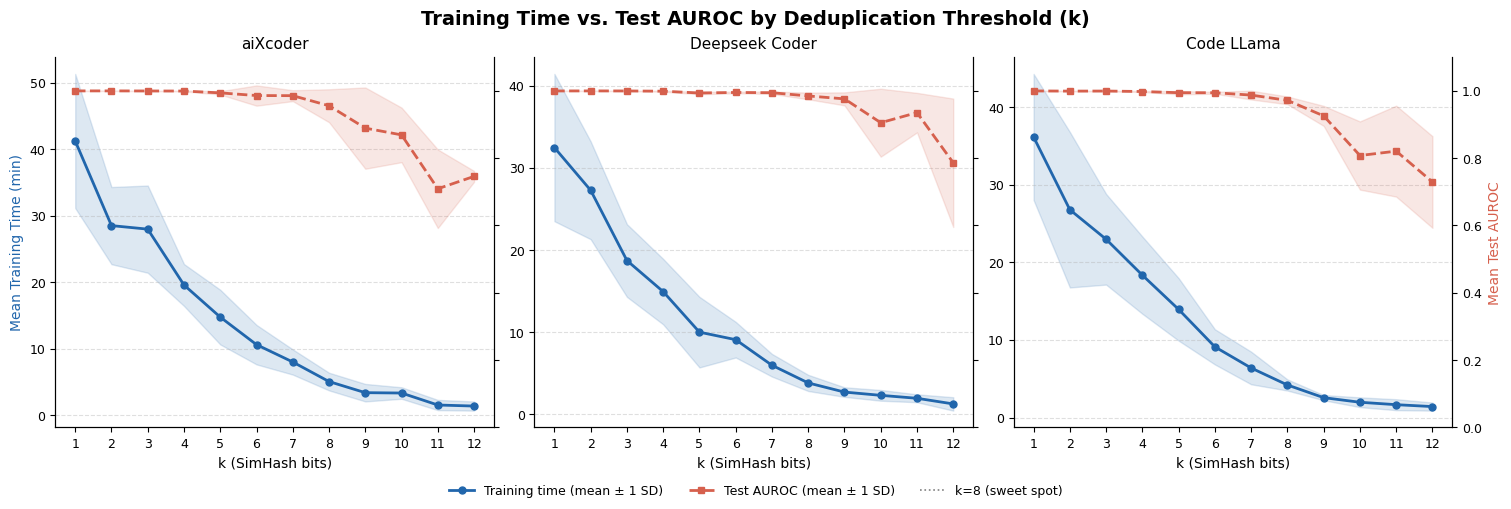

Saved to figures/runtime_vs_test_auroc.pdf and .png


In [13]:

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

EXP_LABELS = {1: "aiXcoder", 2: "Deepseek Coder", 3: "Code LLama"}
TIME_COLOR = "#2166ac"
AUROC_COLOR   = "#d6604d"  # OOD AUROC
K_HIGHLIGHT = 8

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, exp in zip(axes, EXPERIMENTS):
    sub = df[df["experiment"] == exp].sort_values("k")
    ax2 = ax.twinx()

    # --- runtime (left axis) ---
    ax.plot(sub["k"], sub["time_mean_min"], color=TIME_COLOR, lw=2, marker="o", ms=5)
    ax.fill_between(
        sub["k"],
        sub["time_mean_min"] - sub["time_std_min"],
        sub["time_mean_min"] + sub["time_std_min"],
        color=TIME_COLOR, alpha=0.15
    )

    # --- AUROC (right axis) ---
    ax2.plot(sub["k"], sub["auroc_mean"], color=AUROC_COLOR, lw=2, marker="s", ms=5, linestyle="--")
    ax2.fill_between(
        sub["k"],
        sub["auroc_mean"] - sub["auroc_std"],
        sub["auroc_mean"] + sub["auroc_std"],
        color=AUROC_COLOR, alpha=0.15
    )

    # --- k=8 highlight ---
    # ax.axvline(K_HIGHLIGHT, color="gray", lw=1.2, linestyle=":", zorder=0)
    # ax.text(K_HIGHLIGHT + 0.15, ax.get_ylim()[0], f"k={K_HIGHLIGHT}",
    #         color="gray", fontsize=8, va="bottom")

    # --- aesthetics ---
    ax.set_title(EXP_LABELS[exp], fontsize=11)
    ax.set_xlabel("k (SimHash bits)", fontsize=10)
    ax.set_xticks(list(range(1, 13)))
    ax.tick_params(axis="both", labelsize=9)
    ax2.tick_params(axis="y", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    if exp == 1:
        ax.set_ylabel("Mean Training Time (min)", color=TIME_COLOR, fontsize=10)
    if exp == 3:
        ax2.set_ylabel("Mean Test AUROC", color=AUROC_COLOR, fontsize=10)
    else:
        ax2.set_yticklabels([])

    ax2.set_ylim(0.00, 1.10)

legend_elements = [
    Line2D([0], [0], color=TIME_COLOR, lw=2, marker="o", ms=5, label="Training time (mean ± 1 SD)"),
    Line2D([0], [0], color=AUROC_COLOR,   lw=2, marker="s", ms=5, linestyle="--", label="Test AUROC (mean ± 1 SD)"),
    Line2D([0], [0], color="gray",     lw=1.2, linestyle=":", label=f"k={K_HIGHLIGHT} (sweet spot)"),
]
fig.legend(handles=legend_elements, loc="outside lower center", ncol=3, fontsize=9, frameon=False)
fig.suptitle("Training Time vs. Test AUROC by Deduplication Threshold (k)", fontsize=14, fontweight="bold")

plt.savefig("figures/runtime_vs_test_auroc.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/runtime_vs_test_auroc.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to figures/runtime_vs_test_auroc.pdf and .png")


In [ ]:

# ── Experiment 4: GPU resource efficiency vs. model performance ──────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

GPU_SUMMARY = Path("results/experiment4/gpu_utilization_summary.txt")
PERF_CSV    = Path("results/experiment4/results_summary.csv")

# ── 1. Parse gpu_utilization_summary.txt ─────────────────────────────────────
text = GPU_SUMMARY.read_text()

# Split into per-k blocks
blocks = re.split(r"={60}\nGPU Statistics Summary for k=(\d+)\n={60}\n", text)
# blocks[0] = header, then pairs (k_value, block_text)

gpu_records = []
for i in range(1, len(blocks), 2):
    k = int(blocks[i])
    block = blocks[i + 1]

    # Extract per-GPU lines
    gpu_sections = re.split(r"\nGPU (\d+):\n", block)
    for j in range(1, len(gpu_sections), 2):
        gpu_id = int(gpu_sections[j])
        sec    = gpu_sections[j + 1]

        mem_match  = re.search(r"Memory Used:\s+([\d.]+) MB \(mean\)", sec)
        temp_match = re.search(r"Temperature:\s+([\d.]+)°C \(mean\)", sec)
        pow_match  = re.search(r"Power Draw:\s+([\d.]+)W \(mean\)", sec)
        util_match = re.search(r"Utilization \(GPU\):\s+([\d.]+)%", sec)

        gpu_records.append({
            "k": k,
            "gpu": gpu_id,
            "mem_mb": float(mem_match.group(1))  if mem_match  else np.nan,
            "temp_c": float(temp_match.group(1)) if temp_match else np.nan,
            "power_w": float(pow_match.group(1)) if pow_match  else np.nan,
            "util_pct": float(util_match.group(1)) if util_match else np.nan,
        })

gpu_df = pd.DataFrame(gpu_records)

# Separate rank-0 controller GPU from data-parallel workers
worker_df = gpu_df[gpu_df["gpu"] != 0]
rank0_df  = gpu_df[gpu_df["gpu"] == 0]

# Per-k averages across worker GPUs (1-7)
worker_stats = (
    worker_df.groupby("k")
    .agg(
        mem_mb_mean  = ("mem_mb",   "mean"),
        mem_mb_max   = ("mem_mb",   "max"),
        temp_c_mean  = ("temp_c",   "mean"),
        power_w_mean = ("power_w",  "mean"),
        util_pct_mean= ("util_pct", "mean"),
    )
    .reset_index()
    .sort_values("k")
)
worker_stats["mem_gb_mean"] = worker_stats["mem_mb_mean"] / 1024

# Rank-0 memory for reference
rank0_stats = rank0_df.groupby("k")["mem_mb"].mean().reset_index()
rank0_stats.columns = ["k", "rank0_mem_mb"]
rank0_stats["rank0_mem_gb"] = rank0_stats["rank0_mem_mb"] / 1024

# ── 2. Load performance metrics ───────────────────────────────────────────────
perf = pd.read_csv(PERF_CSV).sort_values("k")

# ── 3. Merge ──────────────────────────────────────────────────────────────────
merged = worker_stats.merge(perf[["k", "test_auroc_mean", "test_auroc_std",
                                   "ood_f1_mean", "ood_f1_std"]], on="k")

# ── 4. Summary table ──────────────────────────────────────────────────────────
k1_mem = merged.loc[merged["k"] == 1, "mem_gb_mean"].values[0]
k1_pow = merged.loc[merged["k"] == 1, "power_w_mean"].values[0]
k1_tmp = merged.loc[merged["k"] == 1, "temp_c_mean"].values[0]

merged["mem_reduction_pct"] = (k1_mem - merged["mem_gb_mean"]) / k1_mem * 100
merged["pow_reduction_pct"] = (k1_pow - merged["power_w_mean"]) / k1_pow * 100

print("Experiment 4 — Worker GPU resource savings vs. k=1 baseline\n")
print(f"{'k':>3}  {'Mem(GB)':>8}  {'ΔMem%':>7}  {'Power(W)':>9}  {'ΔPow%':>7}  "
      f"{'Temp(°C)':>9}  {'TestAUROC':>10}  {'OOD F1':>8}")
print("-" * 80)
for _, row in merged.iterrows():
    print(f"{int(row.k):>3}  {row.mem_gb_mean:>8.2f}  {row.mem_reduction_pct:>+7.1f}%  "
          f"{row.power_w_mean:>9.1f}  {row.pow_reduction_pct:>+7.1f}%  "
          f"{row.temp_c_mean:>9.1f}  {row.test_auroc_mean:>10.4f}  {row.ood_f1_mean:>8.4f}")

k8  = merged[merged["k"] == 8].iloc[0]
k12 = merged[merged["k"] == 12].iloc[0]
print(f"\nAt k=8  → {k8.mem_reduction_pct:+.1f}% memory, {k8.pow_reduction_pct:+.1f}% power vs k=1")
print(f"At k=12 → {k12.mem_reduction_pct:+.1f}% memory, {k12.pow_reduction_pct:+.1f}% power vs k=1")

# ── 5. Figure ─────────────────────────────────────────────────────────────────
MEM_COLOR  = "#1a6faf"
POW_COLOR  = "#c94040"
TMP_COLOR  = "#e07b20"
UTIL_COLOR = "#2d9e4e"
F1_COLOR   = "#7b3fa0"
HIGHLIGHT_COLOR = "#888888"
K_HIGHLIGHT = 8

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
(ax_mem, ax_pow), (ax_tmp, ax_util) = axes

k_vals = merged["k"].values

def _twin_f1(ax, color=MEM_COLOR):
    ax2 = ax.twinx()
    ax2.plot(k_vals, merged["ood_f1_mean"], color=F1_COLOR, lw=1.8,
             linestyle="--", marker="s", ms=4, zorder=3)
    ax2.fill_between(k_vals,
                     merged["ood_f1_mean"] - merged["ood_f1_std"],
                     merged["ood_f1_mean"] + merged["ood_f1_std"],
                     color=F1_COLOR, alpha=0.12)
    ax2.set_ylabel("OOD F1 Score", color=F1_COLOR, fontsize=9)
    ax2.tick_params(axis="y", labelcolor=F1_COLOR, labelsize=8)
    ax2.spines["top"].set_visible(False)
    ax2.set_ylim(0.50, 0.85)
    return ax2

def _vline(ax):
    ax.axvline(K_HIGHLIGHT, color=HIGHLIGHT_COLOR, lw=1, linestyle=":", zorder=0)

def _style(ax, ylabel, color):
    ax.set_xlabel("k  (SimHash bit depth — higher k = more aggressive deduplication)", fontsize=8)
    ax.set_ylabel(ylabel, color=color, fontsize=9)
    ax.tick_params(axis="y", labelcolor=color, labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xticks(range(1, 13))
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)

# ── Panel A: Worker GPU memory ────────────────────────────────────────────────
ax_mem.fill_between(k_vals, merged["mem_gb_mean"], alpha=0.2, color=MEM_COLOR)
ax_mem.plot(k_vals, merged["mem_gb_mean"], color=MEM_COLOR, lw=2.2, marker="o", ms=5, zorder=3)
ax_mem.annotate(
    f"−{k12.mem_reduction_pct:.0f}% at k=12",
    xy=(12, k12.mem_gb_mean), xytext=(9.5, k12.mem_gb_mean + 1.2),
    arrowprops=dict(arrowstyle="->", color=MEM_COLOR, lw=1.2),
    color=MEM_COLOR, fontsize=8
)
_vline(ax_mem)
_style(ax_mem, "Worker GPU Memory (GB)", MEM_COLOR)
ax_mem.set_title("A  Worker GPU Memory vs. OOD F1", fontsize=10, fontweight="bold", loc="left")
ax2_mem = _twin_f1(ax_mem)

# ── Panel B: Power draw ───────────────────────────────────────────────────────
ax_pow.fill_between(k_vals, merged["power_w_mean"], alpha=0.2, color=POW_COLOR)
ax_pow.plot(k_vals, merged["power_w_mean"], color=POW_COLOR, lw=2.2, marker="o", ms=5, zorder=3)
ax_pow.annotate(
    f"−{k12.pow_reduction_pct:.0f}% at k=12",
    xy=(12, k12.power_w_mean), xytext=(9.5, k12.power_w_mean + 3),
    arrowprops=dict(arrowstyle="->", color=POW_COLOR, lw=1.2),
    color=POW_COLOR, fontsize=8
)
_vline(ax_pow)
_style(ax_pow, "Mean Worker Power Draw (W)", POW_COLOR)
ax_pow.set_title("B  Power Draw vs. OOD F1", fontsize=10, fontweight="bold", loc="left")
_twin_f1(ax_pow)

# ── Panel C: Temperature ──────────────────────────────────────────────────────
ax_tmp.fill_between(k_vals, merged["temp_c_mean"], alpha=0.2, color=TMP_COLOR)
ax_tmp.plot(k_vals, merged["temp_c_mean"], color=TMP_COLOR, lw=2.2, marker="o", ms=5, zorder=3)
_vline(ax_tmp)
_style(ax_tmp, "Mean Worker GPU Temp (°C)", TMP_COLOR)
ax_tmp.set_title("C  GPU Temperature", fontsize=10, fontweight="bold", loc="left")

# ── Panel D: GPU compute utilization ─────────────────────────────────────────
ax_util.fill_between(k_vals, merged["util_pct_mean"], alpha=0.2, color=UTIL_COLOR)
ax_util.plot(k_vals, merged["util_pct_mean"], color=UTIL_COLOR, lw=2.2, marker="o", ms=5, zorder=3)
ax_util.set_ylim(90, 101)
ax_util.yaxis.set_major_formatter(mticker.PercentFormatter())
_vline(ax_util)
_style(ax_util, "Worker GPU Compute Util. (%)", UTIL_COLOR)
ax_util.set_title("D  GPU Compute Utilization (consistent ≥ 96%)", fontsize=10, fontweight="bold", loc="left")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=MEM_COLOR,  lw=2, marker="o", ms=5, label="Worker GPU memory (GB)"),
    Line2D([0], [0], color=POW_COLOR,  lw=2, marker="o", ms=5, label="Power draw (W)"),
    Line2D([0], [0], color=TMP_COLOR,  lw=2, marker="o", ms=5, label="Temperature (°C)"),
    Line2D([0], [0], color=UTIL_COLOR, lw=2, marker="o", ms=5, label="GPU compute util. (%)"),
    Line2D([0], [0], color=F1_COLOR,   lw=1.8, marker="s", ms=4, linestyle="--",
           label="OOD F1 score (mean ± 1 SD)"),
    Line2D([0], [0], color=HIGHLIGHT_COLOR, lw=1, linestyle=":", label=f"k={K_HIGHLIGHT} (sweet spot)"),
]
fig.legend(handles=legend_elements, loc="outside lower center", ncol=3, fontsize=8.5, frameon=False)
fig.suptitle(
    "Experiment 4 — SimHash Deduplication: GPU Resource Savings with Stable Performance",
    fontsize=12, fontweight="bold"
)

plt.savefig("figures/exp4_gpu_efficiency.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures/exp4_gpu_efficiency.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to figures/exp4_gpu_efficiency.pdf and .png")
